# Beating Python's `list.sort()` with Compiled Radix Sort

This notebook demonstrates a specialized case in which radix sort can outperform Python's built-in `list.sort()`.

## Input assumption

- A large collection of **random, non-negative 32-bit integers**
- Values satisfy $0 \leq x < 2^{32}$
- Numerical data is already available as a contiguous NumPy array with `dtype=np.uint32`
- The original input must be preserved, so both methods sort a copy

## Approach

- **Built-in method:** Python's optimized `list.sort()`
- **Challenger:** Numba-compiled, stable LSD radix sort using base 256
- **Fairness:** Conversion between NumPy arrays and Python lists is kept outside the timer
- **Measurement:** Median of repeated runs
- **Correctness:** Every result is compared with the built-in result

> This is a specialized numerical benchmark. It does not claim that radix sort is better for arbitrary Python objects, strings, negative integers, small inputs, or partially ordered lists.


## What is Numba?

**Numba** is a Just-In-Time, or JIT, compiler for numerical Python. It translates a supported subset of Python and NumPy code into optimized native machine code while the program is running.

```text
Ordinary Python

Source code -> Python interpreter -> repeated interpretation -> result

Numba-compiled function

Source code -> type inference -> LLVM optimization -> machine code -> result
```

Numba is especially useful for:

- numerical loops;
- NumPy arrays;
- simulations;
- mathematical algorithms;
- repeated element-by-element computations;
- specialized integer algorithms such as counting sort and radix sort.

In [47]:
# Installation check
try:
    import numba
    import numpy as np
    print('Numba version:', numba.__version__)
    print('NumPy version:', np.__version__)
except ImportError:
    print('Numba is not installed. Run: %pip install numba')

Numba version: 0.59.0
NumPy version: 1.26.4


## The basic idea of `@njit`

A decorator is placed immediately above a function definition.

```python
from numba import njit

@njit
def function_name(...):
    ...
```

`@njit` requests **nopython mode**. The compiled function runs without using the Python interpreter for its internal numerical operations.

In [48]:
from numba import njit

@njit
def square_sum_numba(n):
    total = 0
    for i in range(n):
        total += i * i
    return total

def square_sum_python(n):
    total = 0
    for i in range(n):
        total += i * i
    return total

print('Python result:', square_sum_python(10))
print('Numba result: ', square_sum_numba(10))

Python result: 285
Numba result:  285


## What happens on the first call?

```text
First call

Arguments
   |
   v
Determine concrete data types
   |
   v
Compile a specialized version
   |
   v
Execute native machine code

Later call with the same types

Arguments -> reuse compiled version -> execute
```

A later call with different argument types may cause Numba to compile another specialized version.

## Timing correctly

A fair experiment separates:

1. **cold time**, which includes compilation;
2. **warm time**, after compilation;
3. ordinary Python execution time.

For very fast functions, use repeated measurements instead of relying on a single run.


In [49]:
from time import perf_counter

N = 2_000_000

# Use a fresh function so that cold-call timing really includes compilation.
@njit
def timed_square_sum_numba(n):
    total = 0
    for i in range(n):
        total += i * i
    return total

start = perf_counter()
r1 = timed_square_sum_numba(N)
cold_time = perf_counter() - start

start = perf_counter()
r2 = timed_square_sum_numba(N)
warm_time = perf_counter() - start

start = perf_counter()
r3 = square_sum_python(N)
python_time = perf_counter() - start

assert r1 == r2 == r3
print(f'Cold Numba call: {cold_time:.6f} s')
print(f'Warm Numba call: {warm_time:.6f} s')
print(f'Ordinary Python:  {python_time:.6f} s')
print(f'Warm speed-up:    {python_time / warm_time:.2f}x')


Cold Numba call: 0.171172 s
Warm Numba call: 0.000084 s
Ordinary Python:  0.617823 s
Warm speed-up:    7320.17x


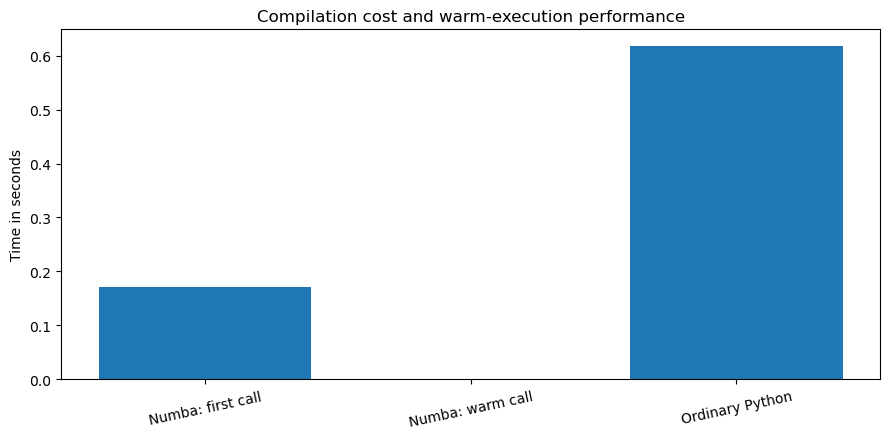

In [50]:
# Visual comparison of the measured times
import matplotlib.pyplot as plt

labels = ['Numba: first call', 'Numba: warm call', 'Ordinary Python']
times = [cold_time, warm_time, python_time]

plt.figure(figsize=(9, 4.5))
plt.bar(labels, times)
plt.ylabel('Time in seconds')
plt.title('Compilation cost and warm-execution performance')
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

## Numba and NumPy arrays

Numba often performs well when explicit loops process homogeneous NumPy arrays.

```text
NumPy array
   |
   v
Compiled loop visits elements
   |
   v
Native arithmetic and memory access
   |
   v
Output array or scalar
```

In [51]:
import numpy as np

@njit
def sum_of_squares_numba(a):
    total = 0.0
    for i in range(a.size):
        total += a[i] * a[i]
    return total

def sum_of_squares_python(a):
    total = 0.0
    for value in a:
        total += value * value
    return total

a = np.linspace(0.0, 1.0, 1_000_000)
sum_of_squares_numba(a)  # warm-up

start = perf_counter()
numba_result = sum_of_squares_numba(a)
numba_time = perf_counter() - start

start = perf_counter()
python_result = sum_of_squares_python(a)
python_loop_time = perf_counter() - start

start = perf_counter()
numpy_result = np.sum(a * a)
numpy_time = perf_counter() - start

print('Results agree:', np.allclose([numba_result, python_result], numpy_result))
print(f'Numba loop:  {numba_time:.6f} s')
print(f'Python loop: {python_loop_time:.6f} s')
print(f'NumPy:       {numpy_time:.6f} s')

Results agree: True
Numba loop:  0.001678 s
Python loop: 0.423786 s
NumPy:       0.014028 s


### Important interpretation

Numba is not automatically faster than every NumPy expression. NumPy already implements many vectorized operations in compiled code. Numba is particularly valuable when:

- the algorithm naturally contains loops or branches;
- several operations can be fused into one pass;
- no convenient vectorized NumPy expression exists;
- temporary arrays would otherwise be created repeatedly.

## Example with branching: Collatz steps


## The Collatz Conjecture

The **Collatz conjecture** is a famous unsolved problem in mathematics. It begins with any positive integer **n**.

At each step:

- If **n is even**, replace **n** by **n / 2**.
- If **n is odd**, replace **n** by **3n + 1**.

In compact form:

**n → n / 2**, if n is even  
**n → 3n + 1**, if n is odd

The conjecture states that repeated application of these rules will eventually produce **1**, regardless of the positive integer chosen.

### Example: Starting with n = 6

**6 → 3 → 10 → 5 → 16 → 8 → 4 → 2 → 1**

Therefore, the starting value **6** requires **8 steps** to reach **1**.

### Another Interesting Example: Starting with n = 27

The sequence beginning with **27** rises to values much larger than 27 before eventually reaching **1**. It requires **111 steps** to reach 1.

This illustrates why the behaviour of Collatz sequences is difficult to predict. Even small starting integers can generate long and irregular sequences.

### What Is a Stopping Time?

In this notebook, the **stopping time** of a positive integer is the number of Collatz steps required for it to reach **1**.

For example:

- The stopping time of **6** is **8**.
- The stopping time of **8** is **3**, since  
  **8 → 4 → 2 → 1**
- The stopping time of **27** is **111**.of \(27\) is \(111\).

### Why is the Collatz problem useful for illustrating Numba?

Computing a Collatz stopping time involves:

1. A `while` loop whose number of iterations is not known in advance.
2. A conditional branch that checks whether the current value is even or odd.
3. Repeated integer arithmetic.
4. Different execution paths for different starting values.

The computational structure is:

```text
Start with n
     |
     v
Is n equal to 1? ---- Yes ----> Stop
     |
     No
     |
     v
Is n even?
   /      \
 Yes       No
  |         |
n = n/2   n = 3n + 1
   \       /
     |
     v
Increase the step counter
     |
     v
Repeat


This example includes a loop and conditional branches, which are awkward to express as one simple NumPy operation.

In [52]:
@njit
def collatz_steps_numba(n):
    steps = 0
    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1
        steps += 1
    return steps

print('Steps for 27:', collatz_steps_numba(27))


Steps for 27: 111


### Numba versus NumPy

NumPy performs best when the same operation can be applied simultaneously to an entire array. However, Collatz sequences have different lengths and follow different branches.

For example:

- One value may be even and follow the rule **n → n / 2**.
- Another value may be odd and follow the rule **n → 3n + 1**.
- Some starting values reach 1 quickly.
- Other starting values require many more iterations.

The NumPy implementation therefore maintains an array of active values. During every iteration, it:

1. identifies the values that have not reached 1;
2. determines which active values are even;
3. applies the appropriate Collatz rule;
4. increments the corresponding step counters;
5. repeats until all values reach 1.

Numba can instead compile the ordinary loops and conditional branches directly into machine code. This makes the Collatz problem useful for comparing vectorized NumPy with compiled, branch-intensive loops.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from numba import njit


# ------------------------------------------------------------
# Numba implementation for one starting integer
# ------------------------------------------------------------

@njit
def collatz_steps_numba(n):
    steps = 0

    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1

        steps += 1

    return steps


# ------------------------------------------------------------
# Numba implementation for several starting integers
# ------------------------------------------------------------

@njit
def collatz_range_numba(limit):
    results = np.empty(limit, dtype=np.int64)

    for n in range(1, limit + 1):
        results[n - 1] = collatz_steps_numba(n)

    return results


# ------------------------------------------------------------
# Vectorized NumPy implementation
# ------------------------------------------------------------

def collatz_range_numpy(limit):
    """
    Calculate the Collatz stopping times for the integers
    1, 2, ..., limit using NumPy array operations.
    """

    # Current Collatz value for every starting integer
    current = np.arange(
        1,
        limit + 1,
        dtype=np.int64
    )

    # Number of steps taken by every starting integer
    steps = np.zeros(
        limit,
        dtype=np.int64
    )

    # Continue until every value has reached 1
    while np.any(current != 1):

        # Identify values that have not yet reached 1
        active = current != 1

        # Identify active even and odd values
        even = active & (current % 2 == 0)
        odd = active & (current % 2 == 1)

        # Apply the Collatz rules
        current[even] //= 2
        current[odd] = 3 * current[odd] + 1

        # Increment the stopping time of active values
        steps[active] += 1

    return steps

In [54]:
# Compile the Numba functions
collatz_range_numba(10)

limit = 100

numba_results = collatz_range_numba(limit)
numpy_results = collatz_range_numpy(limit)

print("First 20 Numba results:")
print(numba_results[:20])

print("\nFirst 20 NumPy results:")
print(numpy_results[:20])

print(
    "\nResults are identical:",
    np.array_equal(numba_results, numpy_results)
)

assert np.array_equal(
    numba_results,
    numpy_results
)

print(
    "\nSteps for 27:",
    numba_results[26]
)

First 20 Numba results:
[ 0  1  7  2  5  8 16  3 19  6 14  9  9 17 17  4 12 20 20  7]

First 20 NumPy results:
[ 0  1  7  2  5  8 16  3 19  6 14  9  9 17 17  4 12 20 20  7]

Results are identical: True

Steps for 27: 111


In [55]:
def mean_execution_time(function, argument, repetitions=5):
    measurements = []

    for _ in range(repetitions):
        start = perf_counter()

        result = function(argument)

        elapsed = perf_counter() - start
        measurements.append(elapsed)

    return np.mean(measurements), result

In [56]:
# Different numbers of starting integers
input_sizes = [
    1_000,
    5_000,
    10_000,
    25_000,
    50_000,
    100_000
]

numba_times = []
numpy_times = []
speedups = []

# Warm-up call
# This ensures that compilation time is not included
# in the main Numba measurements.
collatz_range_numba(100)


for limit in input_sizes:

    numba_time, numba_result = mean_execution_time(
        collatz_range_numba,
        limit
    )

    numpy_time, numpy_result = mean_execution_time(
        collatz_range_numpy,
        limit
    )

    # Verify correctness before comparing performance
    assert np.array_equal(
        numba_result,
        numpy_result
    )

    speedup = numpy_time / numba_time

    numba_times.append(numba_time)
    numpy_times.append(numpy_time)
    speedups.append(speedup)

    print(
        f"N = {limit:>7,} | "
        f"NumPy = {numpy_time:.6f} s | "
        f"Numba = {numba_time:.6f} s | "
        f"Numba speed-up = {speedup:.2f}x"
    )


numba_times = np.asarray(numba_times)
numpy_times = np.asarray(numpy_times)
speedups = np.asarray(speedups)

N =   1,000 | NumPy = 0.024291 s | Numba = 0.000443 s | Numba speed-up = 54.86x
N =   5,000 | NumPy = 0.063908 s | Numba = 0.001929 s | Numba speed-up = 33.13x
N =  10,000 | NumPy = 0.191743 s | Numba = 0.004517 s | Numba speed-up = 42.45x
N =  25,000 | NumPy = 0.452403 s | Numba = 0.017623 s | Numba speed-up = 25.67x
N =  50,000 | NumPy = 0.965850 s | Numba = 0.037276 s | Numba speed-up = 25.91x
N = 100,000 | NumPy = 2.000756 s | Numba = 0.081003 s | Numba speed-up = 24.70x


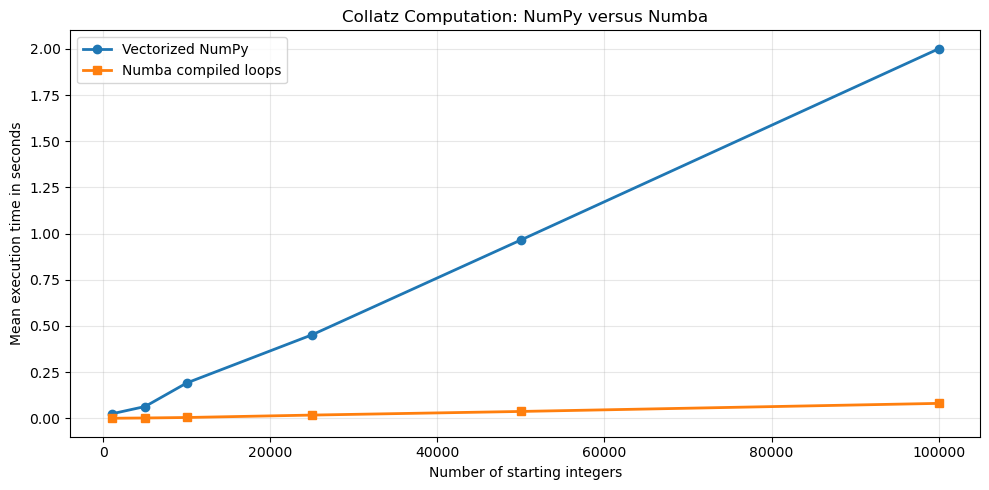

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    input_sizes,
    numpy_times,
    marker="o",
    linewidth=2,
    label="Vectorized NumPy"
)

plt.plot(
    input_sizes,
    numba_times,
    marker="s",
    linewidth=2,
    label="Numba compiled loops"
)

plt.xlabel("Number of starting integers")
plt.ylabel("Mean execution time in seconds")
plt.title("Collatz Computation: NumPy versus Numba")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The NumPy implementation applies operations to arrays of active values. However, Collatz sequences do not all follow the same execution path.

During a particular iteration:

- some values are even;
- some values are odd;
- some values have already reached 1;
- different starting integers require different numbers of iterations.

Therefore, NumPy must repeatedly create Boolean masks and update selected parts of the arrays.

The Numba implementation follows the natural algorithm:

- process one starting integer;
- execute its while loop;
- select the even or odd branch;
- continue until the value reaches 1;
- move to the next starting integer.

Numba compiles these loops and branches into machine code. Therefore, branch-intensive and variable-length numerical computations such as the Collatz calculation may be more suitable for Numba than for vectorized NumPy.

The first Numba call includes compilation time. The benchmark performs a warm-up call before timing so that the graph compares NumPy execution with already-compiled Numba execution.

The exact execution times and speed-up depend on the computer and software environment.

## Why Numba can help Radix Sort

Radix Sort processes fixed-width integer keys in several linear passes.

```text
Example values: 329, 457, 657, 839, 436, 720, 355

Pass 1: group stably by units digit
Pass 2: group stably by tens digit
Pass 3: group stably by hundreds digit
Result: fully sorted sequence
```

Each pass repeatedly performs simple operations such as extracting a digit, incrementing counters, calculating cumulative positions, and moving values. In ordinary Python, all these loop iterations have interpreter overhead. Numba can compile the loops into native code.

## Imports

Numba compiles the radix-sort loops to machine code. This is essential because an ordinary Python-loop implementation is unlikely to beat the highly optimized built-in sorter.

In [58]:
import time
import statistics

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

print("NumPy version:", np.__version__)

NumPy version: 1.26.4


## Compiled base-256 radix sort

A `uint32` value contains 32 bits. Base 256 processes eight bits per pass, so exactly four passes are required:

- `shift = 0`: bits 0 to 7
- `shift = 8`: bits 8 to 15
- `shift = 16`: bits 16 to 23
- `shift = 24`: bits 24 to 31

For each pass, the algorithm:

1. Counts occurrences of each byte value from 0 to 255.
2. Converts frequencies into starting positions.
3. Places values stably in an output array.
4. Uses the output as the input to the next pass.

Stability is necessary because later passes must preserve the ordering established by earlier bytes.

In [59]:
@njit
def radix_sort_uint32(values):
    """Return a stably sorted copy of a NumPy uint32 array."""
    source = values.copy()
    destination = np.empty_like(source)

    # One byte per pass: 4 passes for a 32-bit integer.
    for shift in (0, 8, 16, 24):
        count = np.zeros(256, dtype=np.int64)

        # Step 1: count the current byte values.
        for number in source:
            digit = (number >> shift) & 255
            count[digit] += 1

        # Step 2: convert frequencies into starting positions.
        total = 0
        for digit in range(256):
            frequency = count[digit]
            count[digit] = total
            total += frequency

        # Step 3: stable placement into the destination array.
        for number in source:
            digit = (number >> shift) & 255
            destination[count[digit]] = number
            count[digit] += 1

        # Step 4: exchange the source and destination buffers.
        source, destination = destination, source

    return source

## Direct Python built-in version

`list.sort()` modifies a Python list in place. The wrapper copies the input first so that the original data is preserved, matching the behavior of the radix-sort function.

In [60]:
def python_builtin_sort(values):
    """Return a sorted copy using Python's built-in list.sort()."""
    copied_values = values.copy()
    copied_values.sort()
    return copied_values

## Small correctness demonstration

The same values are represented as a NumPy `uint32` array and a Python list. The two methods must produce identical sorted sequences.

In [61]:
small_numpy = np.array(
    [170, 45, 75, 90, 802, 24, 2, 66],
    dtype=np.uint32
)
small_python = small_numpy.tolist()

# First call also compiles the Numba function.
small_radix_result = radix_sort_uint32(small_numpy)
small_builtin_result = python_builtin_sort(small_python)

print("Original input: ", small_python)
print("Radix result:  ", small_radix_result.tolist())
print("Built-in result:", small_builtin_result)

assert small_radix_result.tolist() == small_builtin_result
print("Correctness check passed.")

Original input:  [170, 45, 75, 90, 802, 24, 2, 66]
Radix result:   [2, 24, 45, 66, 75, 90, 170, 802]
Built-in result: [2, 24, 45, 66, 75, 90, 170, 802]
Correctness check passed.


## Timing

In [62]:
def mean_runtime(function, values, repetitions=5):
    """Return the mean elapsed time and the final result."""
    measurements = []
    result = None

    for _ in range(repetitions):
        start = time.perf_counter()
        result = function(values)
        measurements.append(time.perf_counter() - start)

    return statistics.mean(measurements), result

## Fair benchmark

For each input size:

- One NumPy array of random `uint32` values is generated.
- An equivalent Python list is created **before** timing.
- Both algorithms include the cost of copying their own representation.
- The sorted outputs are checked for equality.

The exact timings will vary by computer. The important question is whether the compiled radix-sort curve remains below the built-in-sort curve for sufficiently large arrays.

In [63]:
rng = np.random.default_rng(42)

sizes = [
    50_000,
    100_000,
    200_000,
    400_000,
    800_000,
    1_600_000,
]

builtin_times = []
radix_times = []
speedups = []

print(
    f"{'Input size':>12}"
    f"{'list.sort() (s)':>18}"
    f"{'Radix (s)':>14}"
    f"{'Speed-up':>12}"
)
print("-" * 56)

for n in sizes:
    numpy_data = rng.integers(
        low=0,
        high=2**32,
        size=n,
        dtype=np.uint32,
    )

    # Representation conversion is deliberately outside the timer.
    python_data = numpy_data.tolist()

    builtin_time, builtin_result = mean_runtime(
        python_builtin_sort, python_data
    )
    radix_time, radix_result = mean_runtime(
        radix_sort_uint32, numpy_data
    )

    # Correctness check without including conversion in the timed region.
    assert radix_result.tolist() == builtin_result

    speedup = builtin_time / radix_time
    builtin_times.append(builtin_time)
    radix_times.append(radix_time)
    speedups.append(speedup)

    print(
        f"{n:12,d}"
        f"{builtin_time:18.6f}"
        f"{radix_time:14.6f}"
        f"{speedup:11.2f}x"
    )

  Input size   list.sort() (s)     Radix (s)    Speed-up
--------------------------------------------------------
      50,000          0.035615      0.001093      32.59x
     100,000          0.093873      0.002088      44.95x
     200,000          0.223993      0.004270      52.46x
     400,000          0.496998      0.008679      57.27x
     800,000          1.132048      0.019811      57.14x
   1,600,000          2.601631      0.052554      49.50x


## Graphical comparison

- The **linear-scale graph** shows actual elapsed times.
- The **logarithmic-scale graph** makes both curves easy to inspect when the difference is large.
- Lower is faster in both graphs.

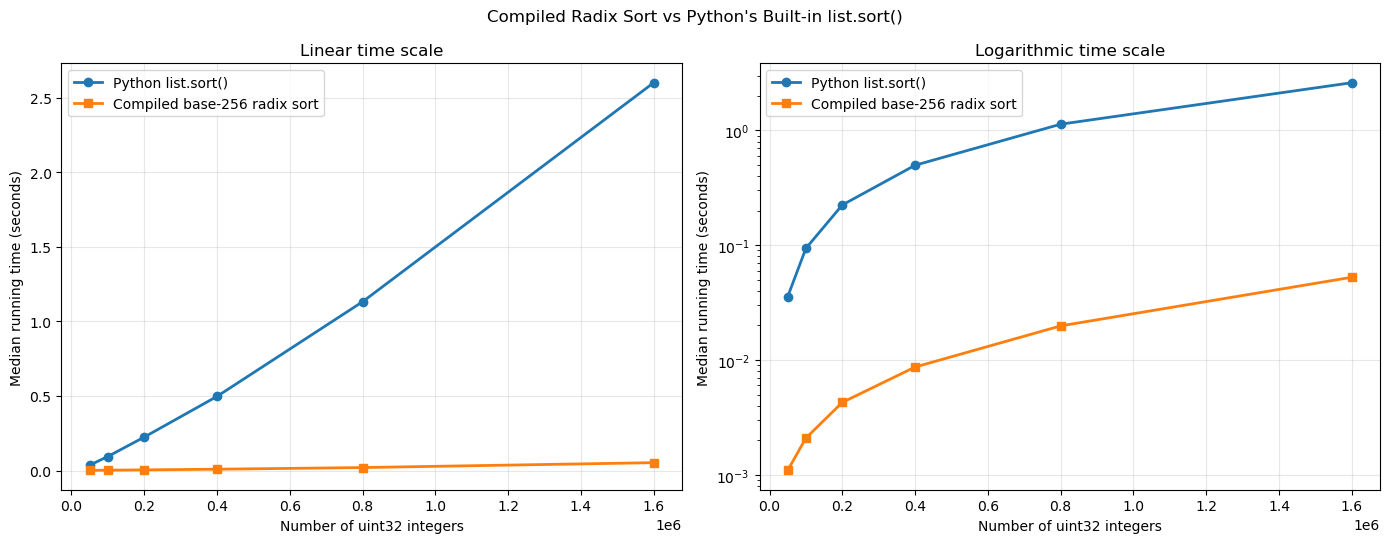

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax in axes:
    ax.plot(
        sizes,
        builtin_times,
        marker="o",
        linewidth=2,
        label="Python list.sort()",
    )
    ax.plot(
        sizes,
        radix_times,
        marker="s",
        linewidth=2,
        label="Compiled base-256 radix sort",
    )
    ax.set_xlabel("Number of uint32 integers")
    ax.set_ylabel("Median running time (seconds)")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_title("Linear time scale")
axes[1].set_title("Logarithmic time scale")
axes[1].set_yscale("log")

fig.suptitle("Compiled Radix Sort vs Python's Built-in list.sort()")
plt.tight_layout()
plt.show()

## Interpretation

### Why the radix sort can win

1. It exploits a restricted key type: fixed-width unsigned integers.
2. It makes exactly four byte-wise passes.
3. It avoids general pairwise comparisons.
4. Numba removes ordinary Python-loop overhead.
5. A contiguous numerical array is more compact than a list of Python integer objects.

### Complexity

For base 256 and four passes, the radix-sort work is

$$O\left(4(n+256)\right)=O(n).$$

A general comparison sort requires approximately $O(n\log n)$ work on random data.

### Important limitations

This radix sorter:

- accepts only `np.uint32` values;
- does not directly handle negative integers;
- uses additional output storage;
- may not win on small inputs;
- is not a replacement for `list.sort()` on arbitrary Python objects;
- requires Numba compilation and a numerical array representation.

## Final conclusion

The best practical radix-sort strategy for beating Python's built-in sorter is a **Numba-compiled, base-256 LSD radix sort operating on a large contiguous `np.uint32` array**. The advantage comes from specialization, fixed-width keys, compiled execution, and avoiding comparison-based ordering.

## EXERCISES

1. Illustrate that python built-in `list.sort()` beats radix sort on an average. What are the algorithms involved in built-in `list.sort()` ?

2. Illustrate that radix sort implemented with numba beats python built-in `list.sort()` on an average. Explain the need for numba in showing that radix sort is faster than python `list.sort()`.

3. What is the largest number of Collatz steps observed on your computer using:

(i) a vectorized NumPy implementation, and
(ii) a Numba implementation?

Do both implementations produce the same maximum number of steps?

4. What are the key takeaways from this lab? How can you apply the concepts and techniques learned in this lab to other computational problems?


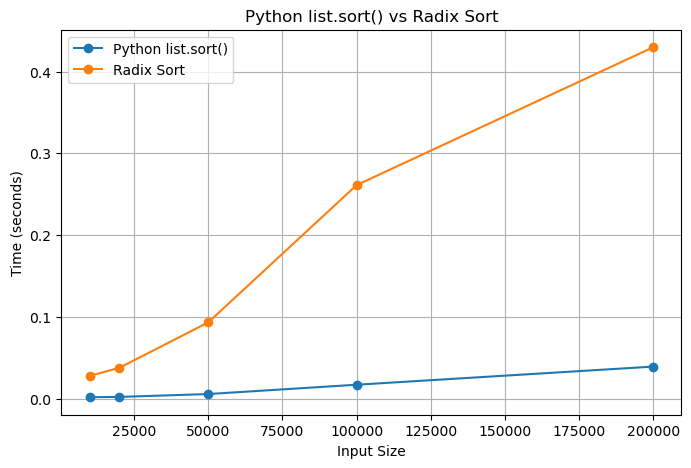

In [5]:
#exercise 1

import random
import time
import numpy as np
import matplotlib.pyplot as plt


def radix_sort(arr):
    arr = arr.copy()

    max_val = max(arr)
    exp = 1

    while max_val // exp > 0:
        output = [0] * len(arr)
        count = [0] * 10

        for x in arr:
            digit = (x // exp) % 10
            count[digit] += 1

        for i in range(1, 10):
            count[i] += count[i - 1]

        for i in range(len(arr) - 1, -1, -1):
            digit = (arr[i] // exp) % 10
            output[count[digit] - 1] = arr[i]
            count[digit] -= 1

        arr = output
        exp *= 10

    return arr


def python_builtin_sort(arr):
    arr = arr.copy()
    arr.sort()
    return arr


sizes = [10000, 20000, 50000, 100000, 200000]

builtin_times = []
radix_times = []

for n in sizes:
    data = [random.randint(0, 10**9) for _ in range(n)]

    start = time.perf_counter()
    result1 = python_builtin_sort(data)
    builtin_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    result2 = radix_sort(data)
    radix_times.append(time.perf_counter() - start)

    assert result1 == result2


plt.figure(figsize=(8, 5))
plt.plot(sizes, builtin_times, marker='o', label="Python list.sort()")
plt.plot(sizes, radix_times, marker='o', label="Radix Sort")

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Python list.sort() vs Radix Sort")
plt.legend()
plt.grid()
plt.show()

Python's built-in list.sort() uses Timsort.

Timsort is a hybrid sorting algorithm combining ideas from:

Merge Sort — used to merge already-sorted runs.
Insertion Sort — used to efficiently sort small runs.

     50000  list.sort(): 0.051169s  radix: 0.000694s  speed-up: 73.77x
    100000  list.sort(): 0.027264s  radix: 0.000665s  speed-up: 41.02x
    200000  list.sort(): 0.042088s  radix: 0.001468s  speed-up: 28.68x
    400000  list.sort(): 0.097760s  radix: 0.004163s  speed-up: 23.48x
    800000  list.sort(): 0.260957s  radix: 0.009264s  speed-up: 28.17x
   1600000  list.sort(): 0.477053s  radix: 0.016788s  speed-up: 28.42x


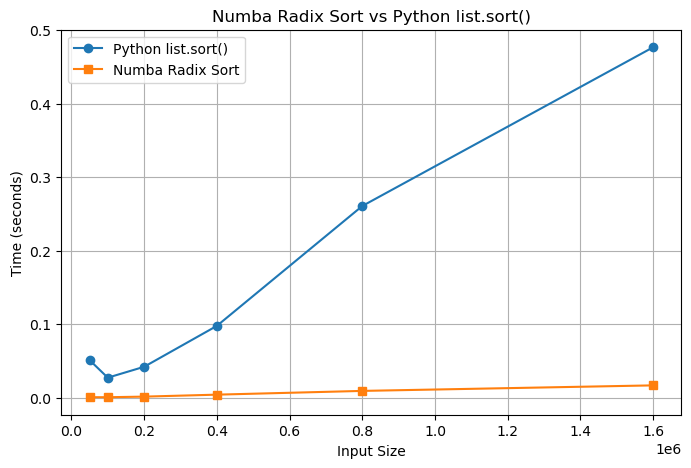

In [6]:
#exercise 2

import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit


@njit
def radix_sort_uint32(values):
    source = values.copy()
    destination = np.empty_like(source)

    for shift in (0, 8, 16, 24):
        count = np.zeros(256, dtype=np.int64)

        for i in range(source.size):
            digit = (source[i] >> shift) & 255
            count[digit] += 1

        total = 0
        for i in range(256):
            c = count[i]
            count[i] = total
            total += c

        for i in range(source.size):
            digit = (source[i] >> shift) & 255
            destination[count[digit]] = source[i]
            count[digit] += 1

        temp = source
        source = destination
        destination = temp

    return source


def python_builtin_sort(values):
    result = values.tolist()
    result.sort()
    return result


sizes = [50000, 100000, 200000, 400000, 800000, 1600000]

builtin_times = []
radix_times = []
speedups = []

# Warm up Numba before timing
radix_sort_uint32(np.array([3, 1, 2], dtype=np.uint32))

for n in sizes:

    data = np.random.default_rng(42).integers(
        0, 2**32, size=n, dtype=np.uint32
    )

    start = time.perf_counter()
    builtin_result = python_builtin_sort(data)
    builtin_time = time.perf_counter() - start

    start = time.perf_counter()
    radix_result = radix_sort_uint32(data)
    radix_time = time.perf_counter() - start

    assert builtin_result == radix_result.tolist()

    builtin_times.append(builtin_time)
    radix_times.append(radix_time)
    speedups.append(builtin_time / radix_time)

    print(
        f"{n:10d}  "
        f"list.sort(): {builtin_time:.6f}s  "
        f"radix: {radix_time:.6f}s  "
        f"speed-up: {builtin_time / radix_time:.2f}x"
    )


plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    builtin_times,
    marker='o',
    label="Python list.sort()"
)

plt.plot(
    sizes,
    radix_times,
    marker='s',
    label="Numba Radix Sort"
)

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Numba Radix Sort vs Python list.sort()")
plt.legend()
plt.grid()
plt.show()

The main reason for using Numba is to make your Radix Sort implementation fast enough for a fair comparison with Python's built-in list.sort().

In [18]:
#exercise 3

N = 100000

numbers = np.arange(1, N + 1)


# Vectorized NumPy implementation
def collatz_steps_numpy(numbers):
    values = numbers.copy()
    steps = np.zeros(len(values), dtype=np.int64)
    active = values != 1

    while np.any(active):
        even = (values % 2 == 0) & active
        odd = (~even) & active

        values[even] //= 2
        values[odd] = 3 * values[odd] + 1

        steps[active] += 1
        active = values != 1

    return steps


# Numba implementation
@njit
def collatz_steps_numba_single(n):
    steps = 0

    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1

        steps += 1

    return steps


@njit
def collatz_steps_numba_all(numbers):
    steps = np.empty(len(numbers), dtype=np.int64)

    for i in range(len(numbers)):
        steps[i] = collatz_steps_numba_single(numbers[i])

    return steps


# Calculate steps
numpy_steps = collatz_steps_numpy(numbers)
numba_steps = collatz_steps_numba_all(numbers)


# Maximum values
numpy_max = np.max(numpy_steps)
numba_max = np.max(numba_steps)

print("Maximum Collatz steps using NumPy :", numpy_max)
print("Maximum Collatz steps using Numba:", numba_max)

print("Do both implementations agree?:", numpy_max == numba_max)

Maximum Collatz steps using NumPy : 350
Maximum Collatz steps using Numba: 350
Do both implementations agree?: True


In [16]:
# Exercise 3 (for specific number)

import numpy as np
from numba import njit

# Enter the number you want to test
N = int(input("Enter a number: "))


# NumPy implementation
def collatz_steps_numpy(n):
    steps = 0

    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1

        steps += 1

    return steps


# Numba implementation
@njit
def collatz_steps_numba(n):
    steps = 0

    while n != 1:
        if n % 2 == 0:
            n //= 2
        else:
            n = 3 * n + 1

        steps += 1

    return steps


# Calculate steps
numpy_steps = collatz_steps_numpy(N)
numba_steps = collatz_steps_numba(N)


# Display results
print("Number:", N)
print("Collatz steps using NumPy :", numpy_steps)
print("Collatz steps using Numba:", numba_steps)
print("Do both implementations agree?:", numpy_steps == numba_steps)

Enter a number: 626331
Number: 626331
Collatz steps using NumPy : 508
Collatz steps using Numba: 508
Do both implementations agree?: True


## Exercise 4

### Key Takeaways

1. Algorithm choice affects the performance of a program.

2. Python built-in functions such as `list.sort()` are highly optimized.

3. Numba can compile numerical Python code into machine code and significantly improve performance.

4. Radix sort can be very fast for fixed-width integer data when implemented using compiled code.

5. NumPy is useful for operations that can be vectorized over an entire array.

6. Numba is useful for problems involving loops, conditions and branching, such as the Collatz problem.

7. Benchmarking should use suitable input sizes and repeated measurements instead of relying on a single execution.

8. The same algorithm can have very different practical performance depending on its implementation.

### Applications

These techniques can be applied to:

- Numerical simulations
- Large-scale data processing
- Scientific computing
- Sorting large integer datasets
- Mathematical computations
- Repeated loop-based calculations

The main lesson is to choose an appropriate algorithm and data representation, then use optimized libraries or compilation techniques when performance is important.